# Q8. What in silico tools currently exist for predicting missense variant pathogenicity, and which are suitable baselines for this project?

**Earlier broader survey.** Current project scope is missense variants only. Splicing and regulatory tools below are background, not candidates for additional project experiments.

**Reviewed 2026-09-07.** A representative survey, not an exhaustive list or benchmark. [Code](src/q8.py) · [Source catalog](src/q8_catalog.json) · [Dependencies](../requirements.txt).

CPU only; runs offline in seconds from a fresh **Gamow** kernel. The bundled notes reproduce this dated review; no variant data, model downloads or random sampling.

In [1]:
from src import q8
survey = q8.load_survey()

12 representative tools · reviewed 2026-09-07 · CPU only · offline
Reproduces the bundled review; no random sampling, inference or benchmark.


## Tool landscape

Colored squares show documented scoring targets, not measured coverage or accuracy. Splicing and expression changes are different endpoints from pathogenicity.

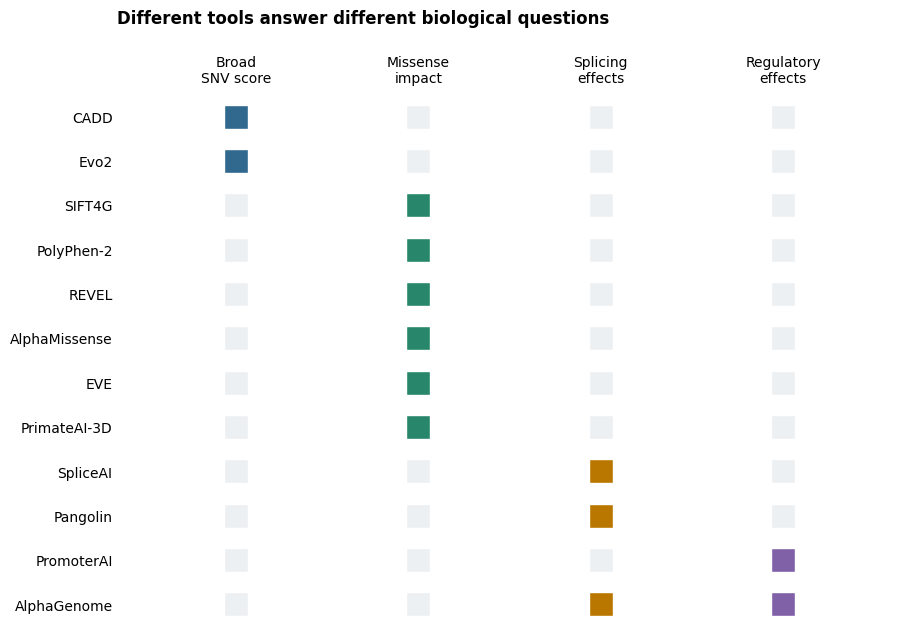

In [2]:
q8.show_landscape(survey)

## Practical comparison

Core training, clinical calibration and published benchmarking are separate sources of possible overlap. The tables include release details, access terms and supporting references.

In [3]:
q8.show_comparison(survey)

Tool,Release,Method,Variants,Inputs,Access,Compute,License,Sources
CADD,1.7 (2024),Annotation ensemble; general deleteriousness ranking.,Coding and noncoding SNVs; short indels can be scored separately.,"GRCh37/GRCh38 chromosome, position, REF and ALT.","Precomputed scores, web service and local scoring.",CPU lookup is the simplest route; local scoring needs annotation resources.,Scores: non-commercial use; commercial use requires contacting the authors.,"Schubach et al. — CADD v1.7 (2024) · CADD — scoring, supported input and usage terms"
Evo2,"2026 model family; project: evo2_1b_base, code 0.6.0",DNA language model; likelihood changes or frozen representations.,"Reference/alternate DNA sequences; this project evaluates SNVs with 1,024-base contexts.","DNA windows; pin checkpoint, strand treatment and scoring rule.",Public code and model weights; project already has a frozen 1B workflow.,GPU inference. Project 1B runtime is documented in Q2; requirements vary by model and context.,Repository and the selected Hugging Face checkpoint: Apache-2.0.,"Evo2 — documented model family, inputs and availability · Evo2 — implementation pinned by this project · Evo2 1B — project checkpoint and model license · Brixi et al. — Genome modelling with Evo2 (2026)"
SIFT4G,2016 method; reviewed source revision pinned,Protein sequence conservation and tolerated amino-acid substitutions.,Missense substitutions; transcript/protein mapping is required for genomic SNVs.,Protein FASTA queries and a homologous protein sequence database.,Public local implementation; annotation databases must match the selected species and reference.,CPU supported; optional CUDA acceleration for database construction/scoring.,Implementation: GPL-3.0; external sequence database terms are separate.,"SIFT4G — source, protein inputs and compute · SIFT4G — GPL-3.0 license · Vaser et al. — SIFT missense predictions for genomes (2016)"
PolyPhen-2,2.2.3r408; choose HumDiv or HumVar explicitly,Supervised protein sequence/structure features.,Missense substitutions in supported proteins.,"Protein accession, residue position and amino-acid substitution; genomic mapping is also available.","Web interface, standalone software and precomputed annotations.",CPU lookup or local scoring with protein/structure databases.,Academic instruction/research use; other use requires the authors' commercial license.,PolyPhen-2 — release 2.2.3r408 and usage terms · PolyPhen-2 — HumDiv and HumVar training data · Adzhubei et al. — PolyPhen-2 protocol (2013)
REVEL,2016 model; official score export updated 2021-05-03,Ensemble of 13 constituent prediction/conservation tools.,Missense SNVs with valid protein/transcript mappings.,Genomic alleles plus transcript/amino-acid mapping; some lifted GRCh38 positions are missing.,Downloadable precomputed score files.,CPU lookup; relatively little work after downloading and indexing scores.,Scores: non-commercial use; contact authors for other uses.,"REVEL — method and training overview · REVEL — 2021 score export, GRCh38 mapping and terms"
AlphaMissense,2023 prediction release; code reference pinned,Protein structure/evolution model with population-frequency supervision.,Human missense substitutions in the released transcript/protein catalog.,"GRCh37/GRCh38 alleles with transcript mapping, or protein substitution identifiers.",Public precomputed predictions and reference code; trained weights are not provided.,CPU lookup of the score release; new inference cannot be reproduced from the published code alone.,Code: Apache-2.0; predictions: CC BY 4.0.,"AlphaMissense — score availability, missing weights and licenses · DeepMind — AlphaMissense training and predictions · Cheng et al. — AlphaMissense (2023) · EMBL-EBI — AlphaMissense score calibration and thresholds"
EVE,2021 method; reviewed source revision pinned,Protein-family generative model followed by mixture-model scoring.,Missense substitutions for proteins and positions covered by the released models.,Protein/re

Tool,Training,Clinvar,Caution,Sources
CADD,Human-derived versus simulated variants; proxy labels rather than direct clinical labels.,ClinVar used for assessment; PolyPhen is an input feature trained on known disease variants.,"Useful broad comparator, but annotation inheritance and clinical assessment prevent a blanket leakage-free claim.","Schubach et al. — CADD v1.7 (2024) · CADD — scoring, supported input and usage terms"
Evo2,Autoregressive training on OpenGenome2 DNA; the project classifier additionally uses training ClinVar labels.,Clinical variants used in published evaluation; exact sequence and annotation contamination are not established here.,A gene-disjoint classifier split does not prove that its pretrained DNA model never encountered those genes.,"Evo2 — documented model family, inputs and availability · Evo2 — implementation pinned by this project · Evo2 1B — project checkpoint and model license · Brixi et al. — Genome modelling with Evo2 (2026)"
SIFT4G,Evolutionary protein sequence alignments; no clinical-label fitting in the core scoring method.,This review does not establish independence of every distributed database or later benchmark.,A protein-impact score is not a calibrated disease probability; missing mappings and alignments limit applicability.,"SIFT4G — source, protein inputs and compute · SIFT4G — GPL-3.0 license · Vaser et al. — SIFT missense predictions for genomes (2016)"
PolyPhen-2,HumDiv/HumVar include known disease/function variants and neutral comparators.,Disease variants can recur in ClinVar even though the original training sources were different.,"Audit the exact model and training overlap; useful as a historical comparator, not an assumed independent reference.",PolyPhen-2 — release 2.2.3r408 and usage terms · PolyPhen-2 — HumDiv and HumVar training data · Adzhubei et al. — PolyPhen-2 protocol (2013)
REVEL,HGMD disease variants and rare neutral variants; constituents bring their own training histories.,ClinVar was a published evaluation set; overlapping variants and inherited labels remain concerns.,Use only with an explicit overlap audit and report mapping failures rather than treating absent scores as benign.,"REVEL — method and training overview · REVEL — 2021 score export, GRCh38 mapping and terms"
AlphaMissense,Human/primate population-frequency labels; core model is not fitted directly to ClinVar classifications.,Released scores are calibrated and category thresholds selected using ClinVar; clinical benchmarking is also reported.,Use continuous scores and audit calibration membership; do not describe this as wholly ClinVar-independent.,"AlphaMissense — score availability, missing weights and licenses · DeepMind — AlphaMissense training and predictions · Cheng et al. — AlphaMissense (2023) · EMBL-EBI — AlphaMissense score calibration and thresholds"
EVE,Evolutionary MSAs; the core workflow requires no clinical labels.,"ClinVar labels are supplied for evaluation, separate from MSA model fitting.",Coverage and homologous-sequence exposure still matter; external clinical calibration would need a separate audit.,"EVE — MSA training, score downloads, ClinVar evaluation and MIT license"
PrimateAI-3D,Common human/primate variation with structural and evolutionary learning objectives.,The authors report clinical benchmarking without relying on clinical annotations for core training.,Exact population and protein overlap are not audited here; availability is gated by the score agreement.,"PrimateAI-3D — score access, academic agreement and PyTorch implementation · Illumina research team — PrimateAI-3D training and scope"
SpliceAI,Annotated splice sites from primary DNA sequence.,Clinical evaluation is separate from the splice-site objective; exact external model exposure is unverified.,Splice disruption is not equivalent to pathogenicity; audit genome/annotation versions and expanded context overlap.,"SpliceAI — variant inputs, model scope and licenses · SpliceAI — software version · Jaganatha

## Earlier baseline shortlist

The earlier shortlist covers several consequence types. Future project comparisons are restricted to missense variants, with frozen [Q1 inputs](Q1-clinvar-split.ipynb), score coverage reporting and external training-data audits.

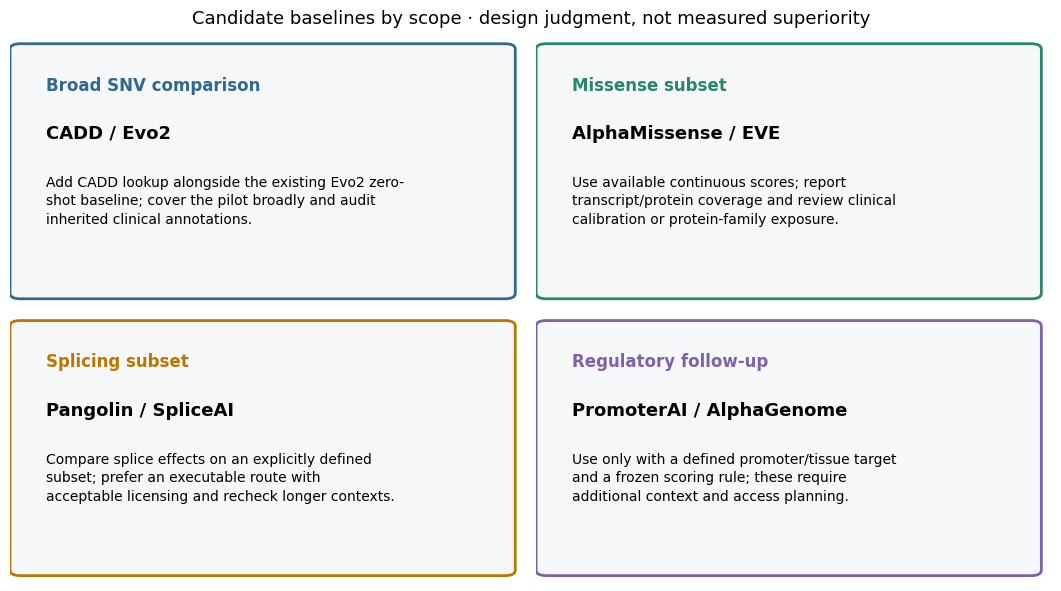

Longer-context models require new overlap checks; Q1’s **1,024-base** grouping is insufficient to certify their contexts.

Survey checks passed; catalog, comparisons, figures and provenance saved to results/q8/.


In [4]:
q8.show_shortlist(survey)
q8.export_results(survey)

[Comparison CSV](results/q8/tool_comparison.csv) · [Survey and citations](results/q8/survey.json) · [Provenance](results/q8/provenance.json)

Catalog checks establish internal consistency only. They do not establish that any model is free of data leakage.

## Earlier broader recommendation

In [5]:
q8.show_conclusion(survey)

Existing tools span broad variant ranking, missense effects, splicing and regulation. For this project, start with CADD alongside Evo2, then AlphaMissense/EVE for missense and Pangolin or SpliceAI for splicing. These are scope-based baseline choices, not a performance ranking; external training and calibration overlap still require auditing.

## Conclusion

The catalog includes missense predictors and broad scorers applicable to missense variants. Compare these within the project’s **missense-only** scope, accounting for coverage and clinical training or calibration overlap. This survey establishes no performance ranking; splicing and regulatory experiments are out of scope.